## 0. Análise exploratória da demanda

O objetivo aqui vai ser explicar como é feito o consumo de cerveja durante os dias da semana. 

1- Verificar se o fim de semana tem grande influencia se comparado aos outros dias.

2- Verificar se o clima tem muita influencia no consumo de cerveja.



## 1. Importação das bibliotecas e carregamento do dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
df = pd.read_csv("../data/processed/consumo_sao_paulo.csv", parse_dates=["data"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                365 non-null    datetime64[us]
 1   temp_media          365 non-null    float64       
 2   temp_min            365 non-null    float64       
 3   temp_max            365 non-null    float64       
 4   chuva_mm            365 non-null    float64       
 5   fim_de_semana       365 non-null    int64         
 6   consumo_mil_litros  365 non-null    float64       
 7   mes                 365 non-null    int64         
 8   dia_semana_num      365 non-null    int64         
 9   dia_semana          365 non-null    str           
dtypes: datetime64[us](1), float64(5), int64(3), str(1)
memory usage: 28.6 KB


In [3]:
df.head()

,data,temp_media,temp_min,temp_max,chuva_mm,fim_de_semana,consumo_mil_litros,mes,dia_semana_num,dia_semana
0,2015-01-01,27.30,23.9,32.5,0.0,0,25.461,1,3,quinta
1,2015-01-02,27.02,24.5,33.5,0.0,0,28.972,1,4,sexta
2,2015-01-03,24.82,22.4,29.9,0.0,1,30.814,1,5,sábado
3,2015-01-04,23.98,21.5,28.6,1.2,1,29.799,1,6,domingo
4,2015-01-05,23.82,21.0,28.3,0.0,0,28.900,1,0,segunda


In [4]:
df.describe()

,data,temp_media,temp_min,temp_max,chuva_mm,fim_de_semana,consumo_mil_litros,mes,dia_semana_num
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.0
mean,2015-07-02 00:00:00,21.226356,17.461370,26.611507,5.196712,0.284932,25.401367,6.526027,3.0
min,2015-01-01 00:00:00,12.900000,10.600000,14.500000,0.000000,0.000000,14.343000,1.000000,0.0
25%,2015-04-02 00:00:00,19.020000,15.300000,23.800000,0.000000,0.000000,22.008000,4.000000,1.0
50%,2015-07-02 00:00:00,21.380000,17.900000,26.900000,0.000000,0.000000,24.867000,7.000000,3.0
75%,2015-10-01 00:00:00,23.280000,19.600000,29.400000,3.200000,1.000000,28.631000,10.000000,5.0
max,2015-12-31 00:00:00,28.860000,24.500000,36.500000,94.800000,1.000000,37.937000,12.000000,6.0
std,NaN,3.180108,2.826185,4.317366,12.417844,0.452001,4.399143,3.452584,2.0


## 2. Análise Univariada

In [5]:
# Configuração visual
sns.set_theme(style="whitegrid")

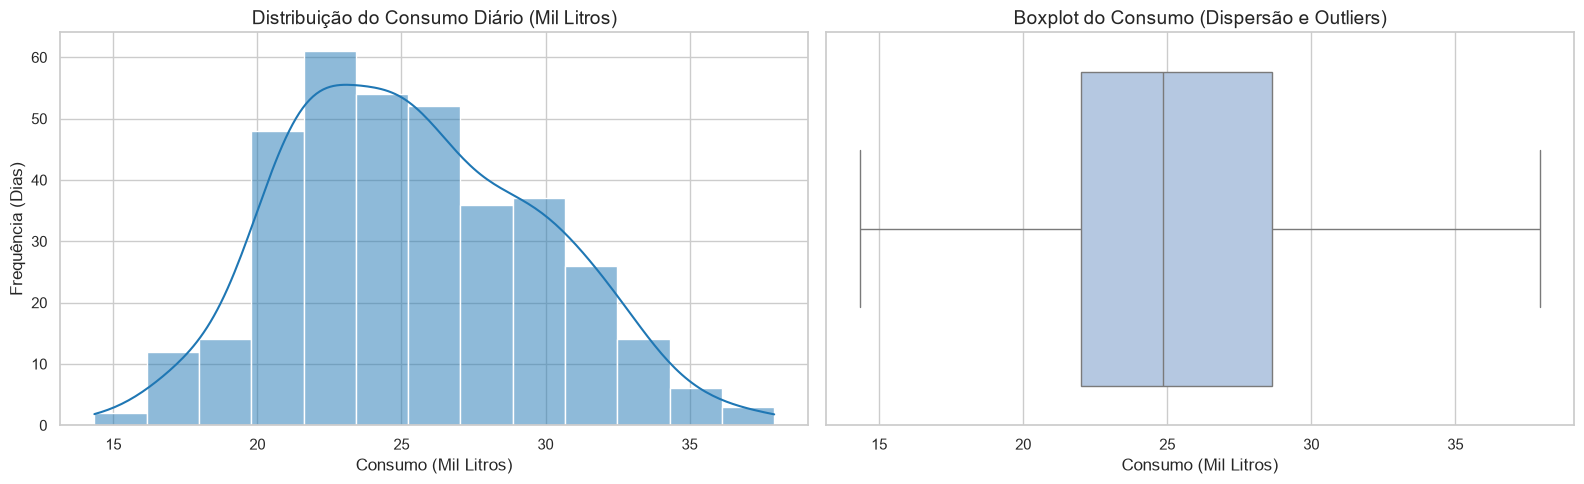

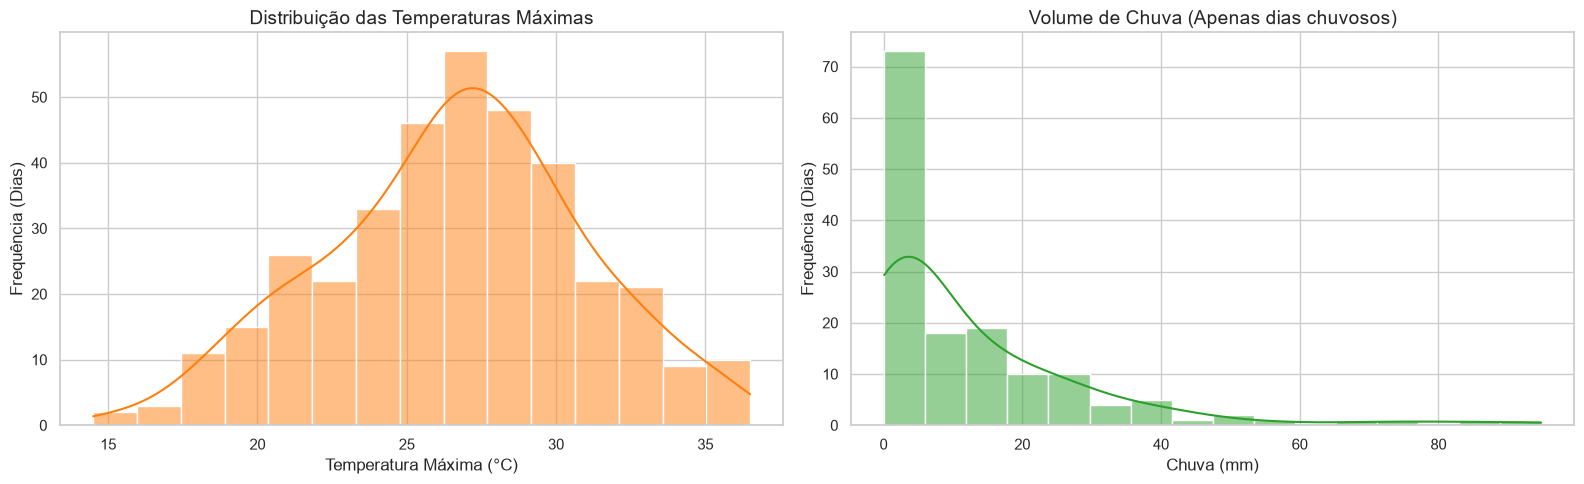

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma: Mostra a frequência de cada faixa de consumo
sns.histplot(df['consumo_mil_litros'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribuição do Consumo Diário (Mil Litros)', fontsize=14)
axes[0].set_xlabel('Consumo (Mil Litros)')
axes[0].set_ylabel('Frequência (Dias)')

# Boxplot: Excelente para encontrar limites normais e outliers (pontos extremos)
sns.boxplot(x=df['consumo_mil_litros'], ax=axes[1], color='#aec7e8')
axes[1].set_title('Boxplot do Consumo (Dispersão e Outliers)', fontsize=14)
axes[1].set_xlabel('Consumo (Mil Litros)')

plt.tight_layout()
fig.savefig("../reports/figures/histogra_e_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 2. Analisando o Clima (Variáveis de Impacto)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Temperaturas Máximas
sns.histplot(df['temp_max'], kde=True, ax=axes[0], color='#ff7f0e')
axes[0].set_title('Distribuição das Temperaturas Máximas', fontsize=14)
axes[0].set_xlabel('Temperatura Máxima (°C)')
axes[0].set_ylabel('Frequência (Dias)')

# Chuva (Filtrando apenas os dias em que choveu para ver o volume)
dias_com_chuva = df[df['chuva_mm'] > 0]
sns.histplot(dias_com_chuva['chuva_mm'], kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Volume de Chuva (Apenas dias chuvosos)', fontsize=14)
axes[1].set_xlabel('Chuva (mm)')
axes[1].set_ylabel('Frequência (Dias)')

plt.tight_layout()
fig.savefig("../reports/figures/dias_chuvos_e_temperatura_maxima", dpi=300, bbox_inches='tight')
plt.show()

## O que os gráficos acima estão nos mostrando ? 

analisando esses gráficos podemos tirar algumas conclusões 

1- a distribuição do consumo de litros fica ali em torno de 20 a 30 mil litros.

2- não há valores extremamentes fora do contexo, sendo assim todos os dados dentro do boxplot sem a presença de outliers 

3- gráfico verde revela que a imensa maioria dos dias chuvosos acumula volumes muito baixos (0 a 15mm), mas existe uma cauda longa de tempestades raras chegando a quase 90mm. A pergunta que fica para o negócio é: uma leve garoa afeta a demanda pela bebida da mesma forma que um temporal intenso?

## 3. Análise Bivariada (Descobrindo Alavancas)

C:\Users\plane\AppData\Local\Temp\ipykernel_26580\308126691.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


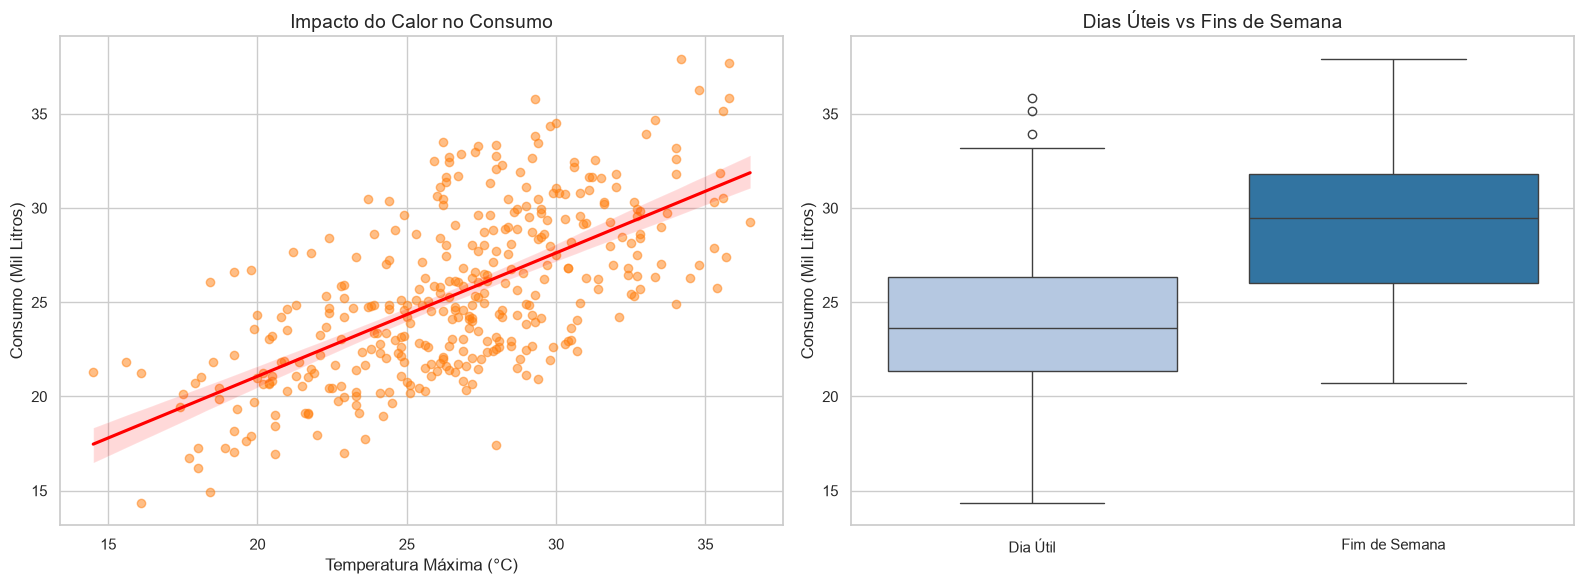

In [7]:
# ==========================================
# 3. Cruzando Variáveis (Análise Bivariada)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Temperatura Máxima vs Consumo
# O regplot já traça uma linha de tendência linear sobre a dispersão
sns.regplot(
    x='temp_max', 
    y='consumo_mil_litros', 
    data=df, 
    ax=axes[0], 
    scatter_kws={'alpha':0.5, 'color': '#ff7f0e'}, 
    line_kws={'color': 'red'}
)
axes[0].set_title('Impacto do Calor no Consumo', fontsize=14)
axes[0].set_xlabel('Temperatura Máxima (°C)')
axes[0].set_ylabel('Consumo (Mil Litros)')

# Gráfico 2: Efeito do Fim de Semana (0 = Dia Útil, 1 = Fim de Semana)
# Mapeando temporariamente para string apenas para deixar o rótulo do eixo X profissional
df['tipo_dia'] = df['fim_de_semana'].map({0: 'Dia Útil', 1: 'Fim de Semana'})

sns.boxplot(
    x='tipo_dia', 
    y='consumo_mil_litros', 
    data=df, 
    ax=axes[1], 
    palette={'Dia Útil': '#aec7e8', 'Fim de Semana': '#1f77b4'}
)
axes[1].set_title('Dias Úteis vs Fins de Semana', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('Consumo (Mil Litros)')

# Removendo a coluna temporária para manter o dataset original intacto
df.drop('tipo_dia', axis=1, inplace=True)

plt.tight_layout()
fig.savefig("../reports/figures/analise_bivariada", dpi=300, bbox_inches='tight')
plt.show()

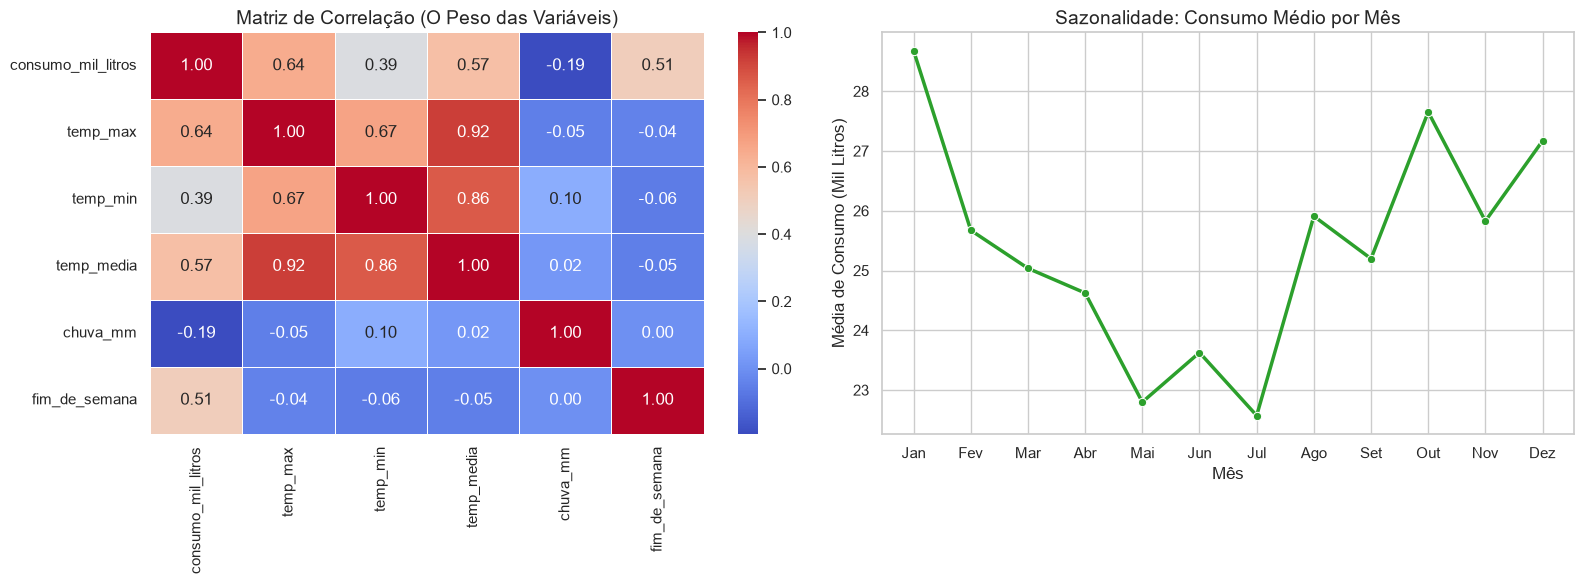

In [8]:
# ==========================================
# 4. Matriz de Correlação e Sazonalidade
# ==========================================
import calendar

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Matriz de Correlação (Heatmap)
# Selecionamos apenas as colunas numéricas para a correlação
colunas_numericas = ['consumo_mil_litros', 'temp_max', 'temp_min', 'temp_media', 'chuva_mm', 'fim_de_semana']
matriz_corr = df[colunas_numericas].corr()

# Plotando o Heatmap
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Cores: azul para correlação negativa, vermelho para positiva
    fmt=".2f",           
    linewidths=.5, 
    ax=axes[0]
)
axes[0].set_title('Matriz de Correlação (O Peso das Variáveis)', fontsize=14)

# Gráfico 2: Evolução Mensal do Consumo
# Agrupando os dados por mês e calculando a média de consumo
consumo_mensal = df.groupby('mes')['consumo_mil_litros'].mean().reset_index()

# Trocando o número do mês pelo nome para ficar profissional no gráfico
meses_pt = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
consumo_mensal['mes_nome'] = consumo_mensal['mes'].map(meses_pt)

sns.lineplot(
    x='mes_nome', 
    y='consumo_mil_litros', 
    data=consumo_mensal, 
    marker='o',   
    color='#2ca02c', 
    linewidth=2.5,
    ax=axes[1]
)
axes[1].set_title('Sazonalidade: Consumo Médio por Mês', fontsize=14)
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Média de Consumo (Mil Litros)')

plt.tight_layout()
fig.savefig("../reports/figures/correlação_e_consumo_meses", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
df.head()

,data,temp_media,temp_min,temp_max,chuva_mm,fim_de_semana,consumo_mil_litros,mes,dia_semana_num,dia_semana
0,2015-01-01,27.30,23.9,32.5,0.0,0,25.461,1,3,quinta
1,2015-01-02,27.02,24.5,33.5,0.0,0,28.972,1,4,sexta
2,2015-01-03,24.82,22.4,29.9,0.0,1,30.814,1,5,sábado
3,2015-01-04,23.98,21.5,28.6,1.2,1,29.799,1,6,domingo
4,2015-01-05,23.82,21.0,28.3,0.0,0,28.900,1,0,segunda


In [11]:
consumo_geral_dia = df.groupby('dia_semana')['consumo_mil_litros'].mean().sort_values()
consumo_geral_dia

dia_semana
segunda    23.609635
quarta     23.810385
quinta     24.076547
sexta      24.137885
terça      24.355154
sábado     28.837923
domingo    29.007519
Name: consumo_mil_litros, dtype: float64

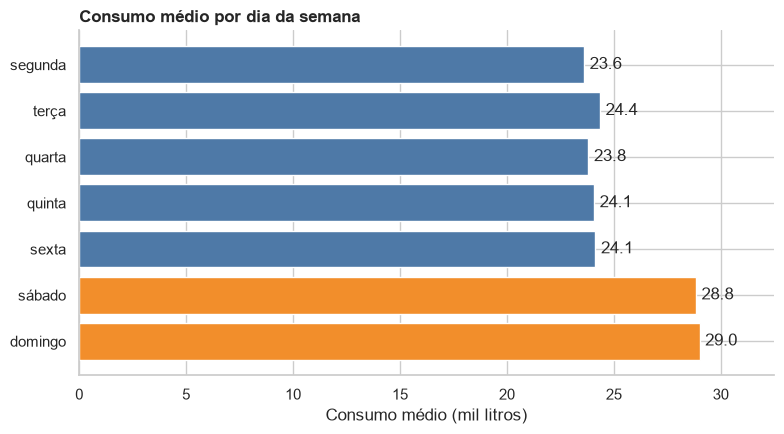

In [13]:
ordem = ['segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado', 'domingo']
consumo = df.groupby('dia_semana')['consumo_mil_litros'].mean().reindex(ordem)

# 2. Uma cor para dia útil e outra para fim de semana
cores = ['#F28E2B' if dia in ['sábado', 'domingo'] else '#4E79A7' for dia in consumo.index]

# 3. Cria a figura e desenha as barras horizontais
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(consumo.index, consumo.values, color=cores)

# 4. Coloca segunda no topo (barh desenha de baixo para cima por padrão)
ax.invert_yaxis()

# 5. Escreve o valor na ponta de cada barra
ax.bar_label(barras, fmt='%.1f', padding=4)

# 6. Títulos e limpeza visual
ax.set_title('Consumo médio por dia da semana', loc='left', fontweight='bold')
ax.set_xlabel('Consumo médio (mil litros)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, consumo.max() * 1.12)  # espaço para os rótulos não cortarem

plt.tight_layout()
plt.savefig("../reports/figures/consumo_medio_dia.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Conclusão da analise

**4.1 matriz de correlação**
- A Temperatura Máxima é a rainha (0.64): Uma correlação positiva de 0.64 é considerada forte. Isso significa que a temperatura dita o ritmo do mercado de forma muito mais agressiva do que o fato de estar chovendo ou não.

- O Efeito Fim de Semana (0.51): Outra correlação fortíssima. O lazer impulsiona as vendas quase tanto quanto o clima.

- O Mito da Chuva (-0.19): Muita gente no negócio acharia que a chuva zera as vendas de cerveja. A matriz prova o contrário. Uma correlação negativa de apenas -0.19 é muito fraca.

**4.2 evolução mensal**
- O Pico (Janeiro): Alta temporada, verão, férias. É o momento de maior faturamento do ano.

- O Vale (Maio/Julho): Outono/Inverno. O consumo despenca para o seu ponto mais baixo. Aqui precisamos segurar despesas e otimizar promoções, pois a demanda orgânica é fraca.

- A Retomada (Agosto em diante): A partir de agosto o mercado começa a aquecer novamente, preparando estoques para a alta temporada de fim de ano.

**Com base nisso podemos dizer que no inverno de São Paulo as vendas caem um pouco e em meses de férias e verão as vendas aumentam bem, sendo necessário uma mudança no estoque.**

